# Analyse
## Vraagstelling

## Het probleem

## Doel van het onderzoek

## Hypothese

# Ethiek

# Cycle I

## Voorbereiding
Voor deze stap heb ik alvast een aantal voorbereidingen getroffen om het werken met de dataset te vereenvoudigen. Het bepalen van sepsis gebeurt op basis van twee scores: de qSOFA-score en de SOFA-score. In de dataset (`test_data.csv`) ontbreken echter enkele variabelen die nodig zijn om deze scores volledig volgens de standaarddefinities te berekenen. Hieronder volgt een overzicht van de beperkingen:

qSOFA-score
De qSOFA-score heeft normaal een bereik van 0–3, maar in deze dataset is dit beperkt tot 0–2, omdat:
- De mentale status (Glasgow Coma Scale, GCS) ontbreekt.

SOFA-score
Ook voor de SOFA-score zijn niet alle componenten volledig beschikbaar:
- Het centrale zenuwstelsel (CNS) kan niet worden meegenomen, aangezien de GCS ontbreekt.
- Voor respiratie wordt de verhouding SpO₂/FiO₂ gebruikt in plaats van de gebruikelijke PaO₂/FiO₂. Deze benadering is minder nauwkeurig.
- De cardiovasculaire (CV) score is slechts gedeeltelijk beschikbaar. Alleen de Mean Arterial Pressure (MAP) wordt gebruikt, waardoor deze component maximaal 1 punt kan bijdragen, terwijl dit normaal kan oplopen tot 4 punten op basis van meerdere metingen.

Om consistent met deze beperkingen om te gaan, is de klasse `SofaCalculator` ontwikkeld. Deze klasse bevat alle logica voor het berekenen van de qSOFA- en SOFA-scores op basis van de beschikbare data. Door deze klasse te importeren in de notebooks, kunnen alle groepsleden dezelfde berekeningsmethode hanteren en wordt inconsistentie in de analyses voorkomen.

In [74]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt

df = pd.read_csv('../data/test_data.csv', sep=',')

De dataset bevat een groot aantal variabelen, namelijk 43 kolommen. Het merendeel hiervan bestaat uit medische metingen die bij patiënten zijn uitgevoerd.

Daarnaast zijn er twee kolommen die betrekking hebben op tijd:
- `HospAdmTime`: HIER UITLEG
- `hour`: De duratie van het ziekenhuisbezoek.

Verder bevat de dataset één kolom zonder naam, waardoor onduidelijk is welke variabele deze vertegenwoordigt en hoe de bijbehorende waarden geïnterpreteerd moeten worden. Ook de kolom `Gender` is niet eenduidig te interpreteren, aangezien de codering van de waarden niet is gespecificeerd.

Op basis van een eerste verkenning van de data (bijvoorbeeld via een `describe`-overzicht) lijken de meeste waarden binnen een realistisch bereik te vallen. Hoewel ik geen medisch specialist ben, lijken eventuele uitschieters mogelijk binnen een ziekenhuiscontext, waar extreme waarden in sommige gevallen kunnen voorkomen.

Wat wel opvalt, is dat de `hour`-kolom waarden bevat tot maximaal 335. Het is niet direct duidelijk hoe deze geïnterpreteerd moeten worden (bijvoorbeeld als uren sinds opname), waardoor het lastig is om te beoordelen of deze waarden correct zijn. Dit brengt enige onzekerheid met zich mee over de interpretatie en betrouwbaarheid van deze specifieke tijdsvariabele.

Ook valt het op dat er veel NaN waardes zijn. Dit kan nutuurlijk zijn omdat de waardes niet gemeten zijn tijdens het ziekenhuis bezoek.

In [75]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152908 non-null  int64  
 1   Hour              152908 non-null  int64  
 2   HR                137741 non-null  float64
 3   O2Sat             132859 non-null  float64
 4   Temp              50922 non-null   float64
 5   SBP               130453 non-null  float64
 6   MAP               133888 non-null  float64
 7   DBP               104056 non-null  float64
 8   Resp              128995 non-null  float64
 9   EtCO2             5616 non-null    float64
 10  BaseExcess        7801 non-null    float64
 11  HCO3              6219 non-null    float64
 12  FiO2              12114 non-null   float64
 13  pH                10002 non-null   float64
 14  PaCO2             8017 non-null    float64
 15  SaO2              5152 non-null    float64
 16  AST               23

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
count,152908.000000,152908.000000,137741.000000,132859.000000,50922.000000,130453.000000,133888.000000,104056.000000,128995.000000,5616.000000,...,9619.000000,923.000000,8966.000000,152908.000000,152908.000000,91365.00000,91365.00000,152908.000000,152908.000000,152908.000000
mean,25.325366,25.325366,84.484206,97.202184,36.974185,123.955092,82.467453,64.157947,18.637462,33.252137,...,11.401586,283.914410,196.699253,62.113354,0.548853,0.49821,0.50179,-55.924729,26.880013,59422.723801
std,29.193743,29.193743,17.153763,2.856418,0.737218,23.481310,16.342338,14.052456,5.091942,8.131784,...,6.717956,148.696373,98.650082,16.261513,0.497609,0.50000,0.50000,126.718883,29.549362,50470.397520
min,0.000000,0.000000,23.000000,20.000000,30.000000,20.000000,20.000000,20.000000,1.000000,10.000000,...,0.100000,35.000000,8.000000,17.000000,0.000000,0.00000,0.00000,-1692.180000,1.000000,2.000000
25%,9.000000,9.000000,72.000000,96.000000,36.500000,107.000000,71.000000,54.000000,15.000000,28.500000,...,7.600000,181.000000,131.000000,51.050000,0.000000,0.00000,0.00000,-49.130000,11.000000,9862.000000
50%,19.000000,19.000000,83.500000,98.000000,37.000000,121.000000,80.000000,62.000000,18.000000,34.000000,...,10.300000,242.000000,182.000000,64.000000,1.000000,0.00000,1.00000,-6.010000,21.000000,20309.000000
75%,33.000000,33.000000,95.000000,99.000000,37.500000,139.000000,92.000000,72.000000,21.000000,38.500000,...,13.800000,350.000000,242.000000,74.210000,1.000000,1.00000,1.00000,-0.040000,34.000000,110348.000000
max,335.000000,335.000000,194.000000,100.000000,41.600000,296.000000,298.000000,296.000000,100.000000,99.000000,...,166.200000,912.000000,1111.000000,100.000000,1.000000,1.00000,1.00000,9.050000,336.000000,119960.000000


In [76]:
df.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
0,0,0,88.5,88.0,38.39,NaN,98.0,NaN,17.0,NaN,...,14.6,NaN,254.0,69.82,1,NaN,NaN,-0.01,3,2136
1,1,1,98.5,94.0,NaN,NaN,100.0,NaN,18.5,NaN,...,14.6,NaN,NaN,69.82,1,NaN,NaN,-0.01,4,2136
2,2,2,102.0,100.0,NaN,NaN,65.0,NaN,20.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,5,2136
3,3,3,102.0,100.0,38.44,NaN,55.0,NaN,19.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,6,2136
4,4,4,97.0,99.0,NaN,NaN,81.0,NaN,23.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,7,2136


Uit deze kolom blijkt dat er zowel boven als onder de maximale waarde veel uitschieters (outliers) aanwezig zijn. Bij `Fibrinogen` is geen vergelijkbaar patroon zichtbaar, al valt dit in de visualisatie deels buiten het diagram om de leesbaarheid te behouden.

Zoals eerder benoemd, is het goed mogelijk dat deze outliers daadwerkelijk valide waarden zijn, aangezien het om medische metingen in een ziekenhuisomgeving gaat, waar extreme waarden kunnen voorkomen. Tegelijkertijd roept de hoeveelheid outliers ook twijfel op over de betrouwbaarheid of interpretatie van sommige metingen.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'HR'),
  Text(1, 0, 'O2Sat'),
  Text(2, 0, 'Temp'),
  Text(3, 0, 'SBP'),
  Text(4, 0, 'MAP'),
  Text(5, 0, 'DBP'),
  Text(6, 0, 'Resp'),
  Text(7, 0, 'EtCO2'),
  Text(8, 0, 'BaseExcess'),
  Text(9, 0, 'HCO3'),
  Text(10, 0, 'FiO2'),
  Text(11, 0, 'pH'),
  Text(12, 0, 'PaCO2'),
  Text(13, 0, 'SaO2'),
  Text(14, 0, 'AST'),
  Text(15, 0, 'BUN'),
  Text(16, 0, 'Alkalinephos'),
  Text(17, 0, 'Calcium'),
  Text(18, 0, 'Chloride'),
  Text(19, 0, 'Creatinine'),
  Text(20, 0, 'Bilirubin_direct'),
  Text(21, 0, 'Glucose'),
  Text(22, 0, 'Lactate'),
  Text(23, 0, 'Magnesium'),
  Text(24, 0, 'Phosphate'),
  Text(25, 0, 'Potassium'),
  Text(26, 0, 'Bilirubin_total'),
  Text(27, 0, 'TroponinI'),
  Text(28, 0, 'Hct'),
  Text(29, 0, 'Hgb'),
  Text(30, 0, 'PTT'),
  Text(31, 0, 'WB

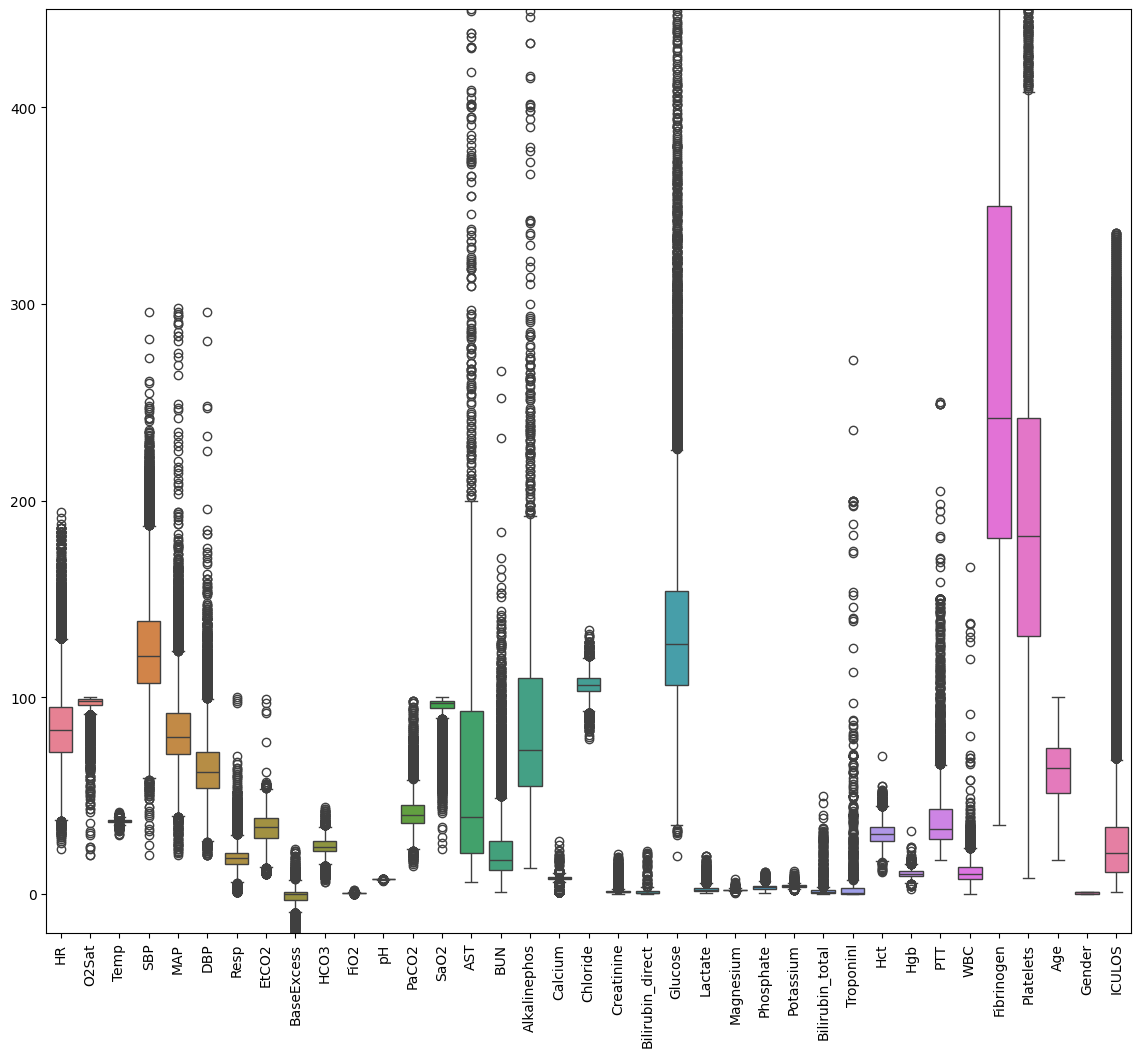

In [77]:
plt.figure(figsize=(14, 12))

sns.boxplot(data=df.drop(columns=['Patient_ID', 'Hour', 'HospAdmTime', 'Unnamed: 0', 'Unit1', 'Unit2']))
plt.ylim(-20, 450)
plt.xticks(rotation=90)

In de kolom `Gender` komen uitsluitend de waarden [0, 1] voor, wat erop wijst dat de variabele gecodeerd is. Hierdoor is op dit moment niet direct te achterhalen welk getal bij welk geslacht hoort binnen deze dataset.

Wel is er een lichte scheve verdeling zichtbaar: waarde 1 komt voor in 54,89% van de gevallen, terwijl waarde 0 in 45,11% van de dataset voorkomt.

In [78]:
df['Gender'].unique()

array([1, 0])

<Axes: xlabel='Gender', ylabel='count'>

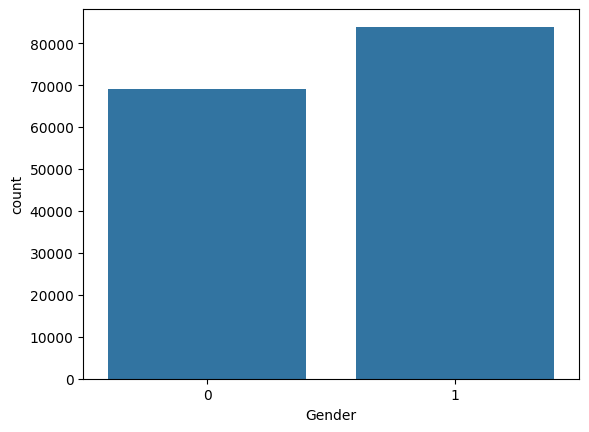

In [79]:
sns.countplot(x=df['Gender'])

Hieronder staat een kleine helperfunctie waarmee het percentage aanwezige waarden in de dataset wordt berekend.

In de eerdere visualisatie was al zichtbaar dat waarde 1 in de `Gender`-kolom vaker voorkomt dan waarde 0. Uit nieuwsgierigheid is vervolgens precies berekend hoe groot dit verschil is in procenten.

In [80]:
def getGenderPercentage(data: pd.DataFrame) -> None: 
    genderLenght = len(data['Gender'])
    gender_vals = data['Gender'].unique()

    def calcPercentage(val: int) -> float:
        return (val /genderLenght) * 100

    for val in gender_vals:
        count = (data['Gender'] == val).sum()
        print(f'{val}: {calcPercentage(count):.2f}%')

getGenderPercentage(df)

1: 54.89%
0: 45.11%


uit dit pariplot durf ik geen conclusies te trekken omdat deze gigantisch is. Een heatmap lijkt mij veel geschikter om de correlatie tussen verschillende gevens te bekijken.

In [81]:
# sns.pairplot(data=df.drop(columns=['Patient_ID', 'Hour', 'HospAdmTime', 'Unnamed: 0', 'Unit1', 'Unit2']))   

De heatmap hieronder is overzichtelijker dan de pairplot die daarna volgt. Er is gekozen voor een driehoekige weergave, zodat dubbele waarden niet worden getoond en de visualisatie compacter blijft.

Annotaties zijn weggelaten, omdat deze de grafiek opnieuw onoverzichtelijk zouden maken, vergelijkbaar met de pairplot.

In [82]:
# corr = data=df.drop(columns=['Patient_ID', 'Hour', 'HospAdmTime', 'Unnamed: 0', 'Unit1', 'Unit2']).corr(numeric_only=True)
# mask = np.triu(np.ones_like(corr, dtype=bool))

# plt.figure(figsize=(14, 12))

# sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm')

Zoals te zien is, bevat de dataset meerdere observaties per Patient_ID, wat erop wijst dat per patiënt meerdere metingen over de tijd zijn vastgelegd. Daarnaast is het mogelijk dat één patiënt meerdere ziekenhuisopnames in de dataset heeft.

In [83]:
df.duplicated(subset=['Patient_ID']).sum()

148908

In [84]:
test = df[['Patient_ID', 'HospAdmTime', 'Hour']].sort_values(by=['Patient_ID', 'Hour'])
test.head(35)

,Patient_ID,HospAdmTime,Hour
885,2,-98.60,0
886,2,-98.60,1
887,2,-98.60,2
888,2,-98.60,3
889,2,-98.60,4
890,2,-98.60,5
891,2,-98.60,6
892,2,-98.60,7
893,2,-98.60,8
894,2,-98.60,9


In [85]:
(test['Patient_ID'] == 2).sum()

23

In deze cyclus wordt afgezien van het gebruik van tijdsreeksen en ligt de nadruk op het toepassen van modellen zoals decision trees en random forests. In een volgende cyclus zal de data verder worden verrijkt. Hierbij zal per meting en per `Patient_ID` een tijdsverschil worden berekend, zodat modellen ontwikkeld kunnen worden die het tijdsverloop expliciet meenemen.

## Data preperation
### Clean Data
De kolom `Unnamed: 0` heeft geen toegevoegde waarde en wordt daarom verwijderd. Het is bekend dat deze kolom een uurwaarde representeert, maar deze informatie is al aanwezig in een aparte kolom. Om redundantie te voorkomen, wordt `Unnamed: 0` niet meegenomen in de verdere analyse.

Daarnaast worden ontbrekende waarden (null values) vervangen door 0. Dit is noodzakelijk omdat de gebruikte modules voor het visualiseren van de decision tree en de random forest geen null-waarden ondersteunen. Aangenomen wordt dat deze ontbrekende waarden het gevolg zijn van metingen die tijdens het ziekenhuisbezoek niet zijn uitgevoerd. Door deze waarden op 0 te zetten, wordt impliciet vastgelegd dat de meting niet heeft plaatsgevonden.

In [86]:
df = df.drop(columns=['Unnamed: 0'])
df = df.fillna(0)

### Construct Data
De enige aanvullende kolommen die nodig zijn, worden berekend en toegevoegd aan de dataset door de `SofaCalculator`. De twee functieaanroepen van de `SofaCalculator` gebruiken vervolgens de gedeeltelijke SOFA-scores om te bepalen of een patiënt wel of geen sepsis heeft.

In [87]:
from Modules.SofaCalculator import SofaCalculator

sofa_calc = SofaCalculator(df)

df = sofa_calc.calculate_all_values()
df['SepsisLabel'] = sofa_calc.hasSepsis()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 45 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Hour                 152908 non-null  int64  
 1   HR                   152908 non-null  float64
 2   O2Sat                152908 non-null  float64
 3   Temp                 152908 non-null  float64
 4   SBP                  152908 non-null  float64
 5   MAP                  152908 non-null  float64
 6   DBP                  152908 non-null  float64
 7   Resp                 152908 non-null  float64
 8   EtCO2                152908 non-null  float64
 9   BaseExcess           152908 non-null  float64
 10  HCO3                 152908 non-null  float64
 11  FiO2                 152908 non-null  float64
 12  pH                   152908 non-null  float64
 13  PaCO2                152908 non-null  float64
 14  SaO2                 152908 non-null  float64
 15  AST              

Hieronder wordt berekend welk percentage van de dataset sepsis heeft en welk percentage niet. Daarbij wordt geen rekening gehouden met het feit dat wanneer bij een patiënt eenmaal sepsis is vastgesteld, deze in de daaropvolgende uren ook sepsis heeft. De berekening gebeurt dus per afzonderlijke rij in de dataset.

Hiervoor is een helpermethode ontwikkeld, die ook op andere momenten in het notebook kan worden aangeroepen om de verdeling opnieuw te controleren na eventuele aanpassingen.

In [88]:
def get_sepsis_values(data: pd.DataFrame) -> None:
    if 'SepsisLabel' not in data.columns:
        raise ValueError("Kolom 'SepsisLabel' ontbreekt in de DataFrame")

    counts = data['SepsisLabel'].value_counts().sort_index()
    total = len(data)

    print('Sepsis verdeling:')
    for val, count in counts.items():
        percentage = (count / total) * 100
        print(f'{val}: aantal = {count}, percentage = {percentage:.2f}%')

get_sepsis_values(df)

Sepsis verdeling:
False: aantal = 146663, percentage = 95.92%
True: aantal = 6245, percentage = 4.08%


### Intergrate Data
Deze stap is in dit geval niet nodig, omdat er slechts met één dataset wordt gewerkt. Er hoeven geen andere datasets samengevoegd te worden, waardoor deze handeling geen toegevoegde waarde heeft. Om die reden wordt deze stap in de volgende cyclus overgeslagen.

### Format Data
Voor het trainen van de modellen wordt de dataset eerst gesplitst in een train- en testset. Hierbij bestaat `X` uit alle variabelen behalve het `sepsislabel` en de twee `unit`-variabelen. Het sepsislabel word gebruikt als de y-variabele, terwijl de `unit`-variabelen uitsluitend worden gebruikt om de dataset op een correcte manier te segmenteren.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SepsisLabel', 'Unit1', 'Unit2'])
y = df['SepsisLabel'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modeling
Voor de eerste cyclus worden twee verschillende modellen ontwikkeld: een decision tree en een random forest. Het random forest is hierbij een uitbreiding op de decision tree. Vervolgens wordt de prestatie van beide modellen met elkaar vergeleken om te bepalen welk model het beste resultaat oplevert.

### Decision Tree
Dit model wordt getraind op basis van het sepsislabel. Hierdoor kan op basis van de SOFA-scores worden voorspeld of een patiënt in de categorie sepsis valt.

In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import dtreeviz

model = DecisionTreeClassifier(max_depth=3, class_weight='balanced')
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

De prestaties van het model zijn uitzonderlijk goed, maar vereisen nadere controle om te bevestigen of dit correct is.

In [91]:
y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29333
           1       1.00      1.00      1.00      1249

    accuracy                           1.00     30582
   macro avg       1.00      1.00      1.00     30582
weighted avg       1.00      1.00      1.00     30582

[[29333     0]
 [    0  1249]]


De visualisatie laat zien hoeveel patiënten in de trainingsdataset op basis van de SOFA-scores als sepsis worden geclassificeerd. Daarnaast zijn er enkele andere variabelen opgenomen, maar deze lijken weinig tot geen invloed te hebben op deze classificatie.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTre

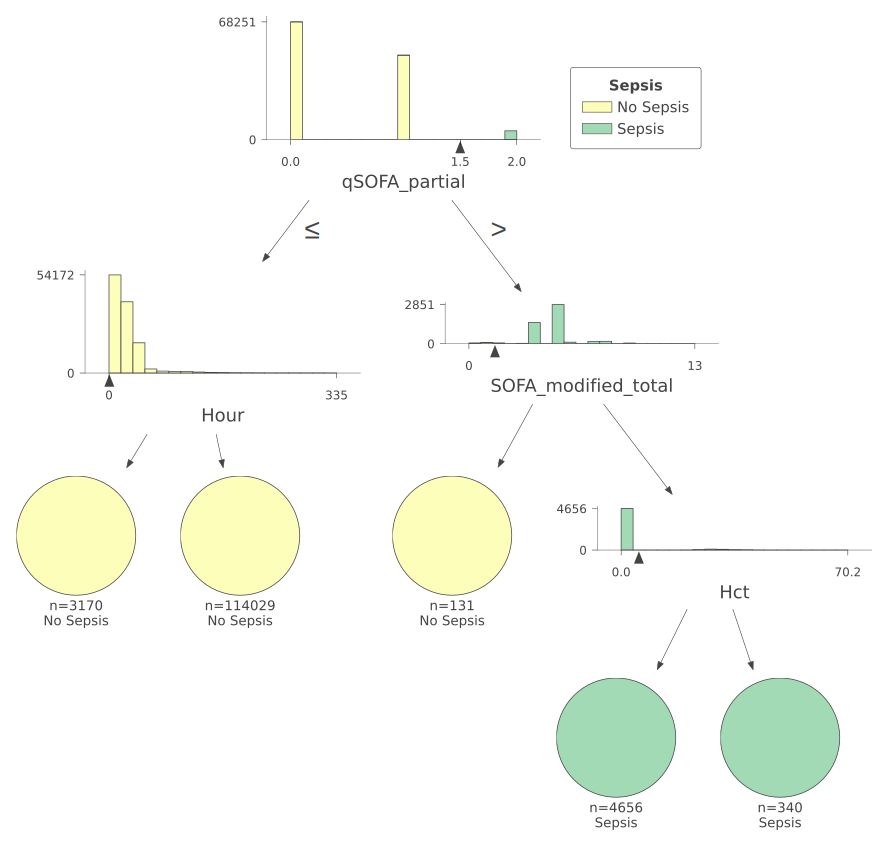

In [92]:
f_model = dtreeviz.model(
    model,
    x_train,
    y_train,
    feature_names=x_train.columns,
    target_name='Sepsis',
    class_names=["No Sepsis", "Sepsis"]
)

f_model.view(scale=2)

## Random forest

Net als bij het vorige model wordt ook dit model getraind om het sepsislabel te herkennen. Dit gebeurt op een vergelijkbare manier als bij de decision tree.

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        
    max_depth=10,           
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                
)

rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Net zoals bij het voirge lijkt dit model perfect. Dit is heel onwaarschijnlijk en moet dus ook nader na gekekn worden of dit wel correct is.

In [94]:
y_pred = rf_model.predict(x_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29333
           1       1.00      1.00      1.00      1249

    accuracy                           1.00     30582
   macro avg       1.00      1.00      1.00     30582
weighted avg       1.00      1.00      1.00     30582

[[29333     0]
 [    0  1249]]


Omdat dit model, net als een decision tree, gebruikmaakt van boomstructuren, kijkt het niet naar één enkele boom maar naar meerdere bomen om te bepalen of iemand wel of niet aan het sepsislabel voldoet. Door deze combinatie van meerdere bomen kan het model verschillende patronen meenemen in de beslissing. Daarom lijkt dit model geschikter dan een enkele decision tree, omdat het op basis van meer informatie en perspectieven tot een eindbeslissing komt.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

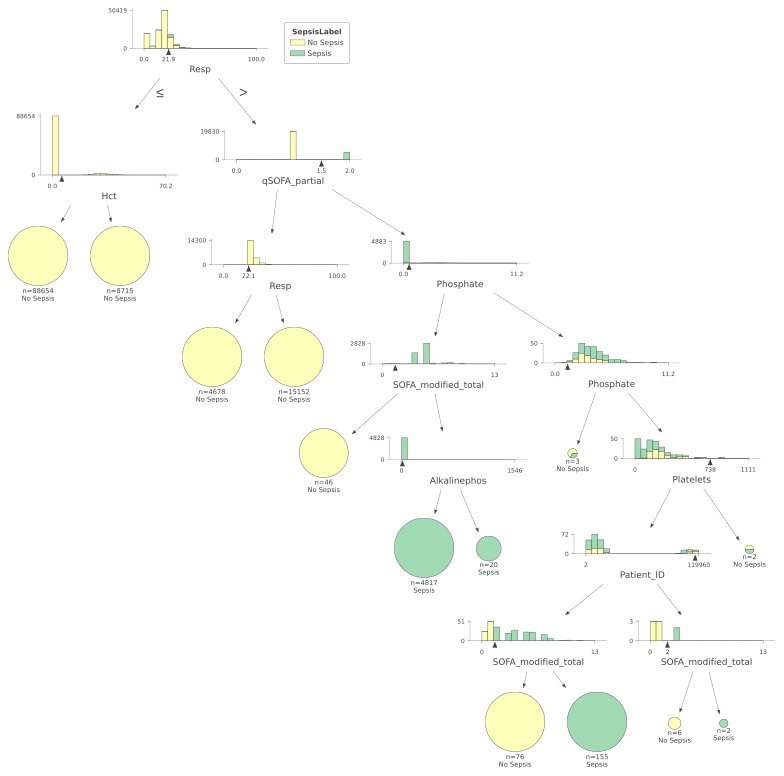

In [95]:
rf_tree = rf_model.estimators_[0]

rf_tree_model = dtreeviz.model(
    rf_tree,
    x_train,
    y_train,
    feature_names=x_train.columns,
    target_name='SepsisLabel',
    class_names=["No Sepsis", "Sepsis"]
)

rf_tree_model.view()

### Reflectie
Zoals bij beide modellen al benoemd, lijken de prestaties te goed. De nauwkeurigheid ligt vrijwel rond de 100%. In de praktijk is dit echter onrealistisch, zeker omdat de dataset nog beperkt is bewerkt en nog niet volledig is opgeschoond. Een belangrijke factor hierin is de aanwezigheid van ontbrekende data. Het gaat hierbij onder andere om kolommen die door de `SofaCalculator` worden gebruikt om de SOFA-scores en bijbehorende sepsislabels te berekenen.

Op dit moment baseert het model zijn voorspellingen slechts op een beperkt aantal variabelen, zonder rekening te houden met hoe deze waarden daadwerkelijk bijdragen aan het ontstaan van het sepsislabel. Die onderliggende relaties zijn in deze fase nog niet goed meegenomen, onder andere doordat er fouten optraden bij het verwerken en combineren van de relevante tabellen.

Daarnaast laten evaluatiemethoden zoals het `classification_report` en de `confusion_matrix` uitzonderlijk hoge scores zien. Hoewel dit op het eerste gezicht wijst op een sterk model, is dit waarschijnlijk misleidend. Het is aannemelijk dat er iets mis is gegaan bij het splitsen van de data in trainings- en testsets. Mogelijk is er sprake van overfitting of van datalekken, waarbij de testdata niet goed gescheiden is van de trainingsdata.

In de volgende iteratie zal de focus daarom liggen op het verbeteren van de datakwaliteit en het correct verwerken van ontbrekende waarden. Ook zullen er extra kolommen worden toegevoegd die nodig zijn voor het berekenen van de qSOFA- en SOFA-scores.

Hoewel beide modellen opnieuw zullen worden geëvalueerd, ligt de voorkeur op dit moment bij het random forest-model. Dit model is doorgaans beter in staat om complexe patronen te leren en presteert vaak robuuster wanneer de dataset uitgebreider en informatiever wordt.

# Cycle II
oals hierboven beschreven, ligt de focus van deze cyclus voornamelijk op het verbeteren van de datakwaliteit en de verwerking ervan. Daarnaast is het belangrijk om de data op te splitsen in een train- en testset. Op die manier wordt beoogd de prestaties en betrouwbaarheid van de modellen te verbeteren.

## Voorbereiding
De eerdere stappen waren grotendeels nog steeds noodzakelijk, en het zou zonde zijn om deze opnieuw uit te voeren. Wat wél opnieuw moet gebeuren, is het meenemen van de overige data die bijdragen aan het bepalen van het `sepsislabel`. Om dit te realiseren, worden eerst de bestaande kolommen die hierop betrekking hebben verwijderd en vervolgens opnieuw berekend. 

Hier worden eerst de kolommen verwijders om ze opnieuw te berekenen.

In [96]:
df = df.drop(columns=['qSOFA_partial', 'SOFA_modified_total', 'SepsisLabel'])

Hieronder worden de herberekeningen van deze waarden weergegeven. Dit keer worden de extra kolommen die nodig zijn voor de berekeningen wel in de dataset opgenomen. Daarnaast wordt het `sepsislabel` opnieuw toegevoegd aan de dataset.

In [97]:
sofa_calc = SofaCalculator(df)

df = sofa_calc.calculate_all_values(True, True)
df['SepsisLabel'] = sofa_calc.hasSepsis()

Hier is te zien dat er enkele extra kolommen zijn toegevoegd waarmee de SOFA-scores worden berekend. Dit betreft de variabelen `qsofa_resp`, `qsofa_sbp`, `SF_ratio`, `sofa_resp`, `sofa_coag`, `sofa_liver`, `sofa_cv` en `sofa_renal`. Deze waarden vormen de basis voor de punten waaruit de SOFA-scores worden opgebouwd.

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 53 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Hour                 152908 non-null  int64  
 1   HR                   152908 non-null  float64
 2   O2Sat                152908 non-null  float64
 3   Temp                 152908 non-null  float64
 4   SBP                  152908 non-null  float64
 5   MAP                  152908 non-null  float64
 6   DBP                  152908 non-null  float64
 7   Resp                 152908 non-null  float64
 8   EtCO2                152908 non-null  float64
 9   BaseExcess           152908 non-null  float64
 10  HCO3                 152908 non-null  float64
 11  FiO2                 152908 non-null  float64
 12  pH                   152908 non-null  float64
 13  PaCO2                152908 non-null  float64
 14  SaO2                 152908 non-null  float64
 15  AST              

Bij de SF_ratio zijn een aantal afwijkende waarden zichtbaar, waaronder inf en NaN. Deze waarden moeten worden gecorrigeerd of verwerkt, zodat ze bruikbaar zijn in de verdere analyse. De overige waarden lijken wel correct en hoeven niet aangepast te worden.

In [99]:
df.describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,qsofa_resp,qsofa_sbp,qSOFA_partial,SF_ratio,sofa_resp,sofa_coag,sofa_liver,sofa_cv,sofa_renal,SOFA_modified_total
count,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000,...,152908.000000,152908.000000,152908.000000,133235.0,133235.000000,152908.000000,152908.000000,152908.000000,152908.000000,152908.000000
mean,25.325366,76.104187,84.457223,12.313283,105.751913,72.209448,43.660366,15.722784,1.221283,-0.039364,...,0.204162,0.279626,0.483788,inf,0.225068,3.794275,0.010019,0.313895,0.038167,4.352467
std,29.193743,30.047016,32.916567,17.430997,48.943174,31.218277,32.083008,8.228013,6.445716,0.975350,...,0.403089,0.448817,0.577644,NaN,0.746478,0.846191,0.155275,0.464076,0.304217,1.129322
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-26.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,68.000000,94.000000,0.000000,98.000000,66.000000,0.000000,13.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,4.000000,0.000000,0.000000,0.000000,4.000000
50%,19.000000,81.000000,97.000000,0.000000,116.000000,78.000000,55.000000,17.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,4.000000,0.000000,0.000000,0.000000,4.000000
75%,33.000000,94.000000,99.000000,36.500000,135.000000,90.000000,67.000000,20.500000,0.000000,0.000000,...,0.000000,1.000000,1.000000,NaN,0.000000,4.000000,0.000000,1.000000,0.000000,5.000000
max,335.000000,194.000000,100.000000,41.600000,296.000000,298.000000,296.000000,100.000000,99.000000,23.000000,...,1.000000,1.000000,2.000000,inf,4.000000,4.000000,4.000000,1.000000,4.000000,13.000000


Door het kijken naar deze rows vallen er geen andere dingen op.

In [100]:
df.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,qsofa_sbp,qSOFA_partial,SF_ratio,sofa_resp,sofa_coag,sofa_liver,sofa_cv,sofa_renal,SOFA_modified_total,SepsisLabel
0,0,88.5,88.0,38.39,0.0,98.0,0.0,17.0,0.0,-2.0,...,1,1,88.0,4.0,0,0,0,1,5.0,False
1,1,98.5,94.0,0.00,0.0,100.0,0.0,18.5,0.0,-2.0,...,1,1,188.0,3.0,4,0,0,0,7.0,False
2,2,102.0,100.0,0.00,0.0,65.0,0.0,20.0,0.0,0.0,...,1,1,inf,0.0,4,0,1,0,5.0,False
3,3,102.0,100.0,38.44,0.0,55.0,0.0,19.0,0.0,0.0,...,1,1,inf,0.0,4,0,1,0,5.0,False
4,4,97.0,99.0,0.00,0.0,81.0,0.0,23.0,0.0,0.0,...,1,2,inf,0.0,4,0,0,0,4.0,True


Een aantal kolommen in deze dataset bevat nog ontbrekende waarden (`null`). Deze worden, net als in de vorige cyclus, later vervangen door 0. Dit wordt gedaan om aan te geven dat deze waarden niet zijn gemeten.

In [101]:
df.isnull().sum()

Hour                       0
HR                         0
O2Sat                      0
Temp                       0
SBP                        0
MAP                        0
DBP                        0
Resp                       0
EtCO2                      0
BaseExcess                 0
HCO3                       0
FiO2                       0
pH                         0
PaCO2                      0
SaO2                       0
AST                        0
BUN                        0
Alkalinephos               0
Calcium                    0
Chloride                   0
Creatinine                 0
Bilirubin_direct           0
Glucose                    0
Lactate                    0
Magnesium                  0
Phosphate                  0
Potassium                  0
Bilirubin_total            0
TroponinI                  0
Hct                        0
Hgb                        0
PTT                        0
WBC                        0
Fibrinogen                 0
Platelets     

Binnen de `SF_ratio` komen opvallend veel `inf`-waarden voor. Dit is waarschijnlijk het gevolg van de manier waarop deze ratio wordt berekend. In de berekening wordt geen rekening gehouden met het voorkomen van `NaN`-waarden, wat ertoe kan leiden dat er ongeldige of oneindige (`inf`) resultaten ontstaan.

In [102]:
np.isinf(df['SF_ratio']).sum()

121125

## Data preperation
Voordat de data kan worden gebruikt voor de nieuwe modellen, moeten nog enkele kleine aanpassingen worden doorgevoerd. Dit wordt gedaan met als doel om deze keer tot een beter presterend model te komen.

### Clean Data 
Hier worden eerst alle `inf`-waarden vervangen door 0. Vervolgens worden ook alle `null`-waarden aangepast. Dit wordt gedaan om de data consistent te maken met andere niet-gemeten waarden.

In [103]:
df['SF_ratio'] = df['SF_ratio'].replace([np.inf, -np.inf], 0)
df = df.fillna(0)

### Construct Data
Het enige dat hier aan de dataset wordt toegevoegd is `Sepsis_Future`. Deze kolom geeft aan of iemand, op basis van de SOFA-waardes, zes uur later sepsis heeft of niet. Hiermee kan worden geanalyseerd of iemand volgens de gekozen criteria sepsis ontwikkelt en hoe deze verdeling eruitziet.

Om dit te realiseren wordt de dataset eerst gesorteerd op `Patient_ID` en `Hour`, waarbij `Hour` aangeeft hoeveel uur een patiënt al in het ziekenhuis is opgenomen.

In [ ]:
df = df.sort_values(['Patient_ID', 'Hour'])
df['Sepsis_Future'] = df.groupby('Patient_ID')['SepsisLabel'].shift(-6)

Over deze stap is nog niet volledig duidelijk of deze noodzakelijk is. Hierbij worden alle rijen verwijderd waarvoor geen `Sepsis_Future`-waarde beschikbaar is. Voor het opschonen van de dataset, voorafgaand aan het trainen van het model, lijkt dit echter wel een zinvolle stap. Aangezien er geen data aanwezig is voor sommige patienten na een `X` aantal uren. Dit word dan automatisch als `NaN` gezet.

In [ ]:
df = df.dropna(subset=['Sepsis_Future'])

### Format Data

In [ ]:
features = ['heart_rate', 'resp_rate', 'blood_pressure']

X = df[features]
y = df['sepsis_future']

patients = df['patient_id'].unique()

KeyError: "None of [Index(['heart_rate', 'resp_rate', 'blood_pressure'], dtype='object')] are in the [columns]"

In [ ]:
train_patients, test_patients = train_test_split(
    patients, test_size=0.2, random_state=42
)

In [ ]:
train_df = df[df['patient_id'].isin(train_patients)]
test_df = df[df['patient_id'].isin(test_patients)]

X_train = train_df[features]
y_train = train_df['sepsis_future']

X_test = test_df[features]
y_test = test_df['sepsis_future']

## Modeling

# Cycle III

## Voorbereiding

## Data preperation
### Clean Data

### Construct Data

### Format Data

## Modeling